# Analysis — N Particles

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from aux_functions import shorten_points, make_fitting_func, adj_data_shape, fit_curve, adj_ph, adj_omega

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [ ]:
data_path_exc = './experimental_data/05-04-26/exc_laser30mA_OD'

data_paths_lum = [ 
    # "./experimental_data/25-03-26/lum_laser200mA_counts7k_ODmax",
    # "./experimental_data/26-03-26/particle1/lum_laser100mA_counts2k_ODmax",
    # "./experimental_data/05-04-26/GPTIM_laser800mA_counts_50k",
    # "./experimental_data/05-04-26/LRTIM_laser800mA_counts_50k",
    # "./experimental_data/05-04-26/GPTIM_laser800mA_counts_50k",
    "./experimental_data/06-04-26/p1_lum_laser700mA_counts2700"
    ]

# Correção de fase por partícula (True aplica x -> x-360 quando x > 180)
adj_phase_correction = [False, False, False]
# Se tiver mais partículas que entradas aqui, as extras usam False por padrão.

# # Lista de frequências usadas nos experimentos
freq_list = [
    "2","3","6","10",
    "20","30","60","100",
    "200","300","600","1000",
    "2000","3000","6000","10000",
    # "2","3","4","6","10",
    # "20","30","40","60","100",
    # "200","300","400","600","1000",
    # "2000","3000","4000","6000","10000",
    ]

fitting_problems = [
    {"600": [-1002.55191666,  5270.13576478,   -51.22739728]},
    {}
    ]

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))

## Análise — loop sobre N partículas


  Processing Particle 1


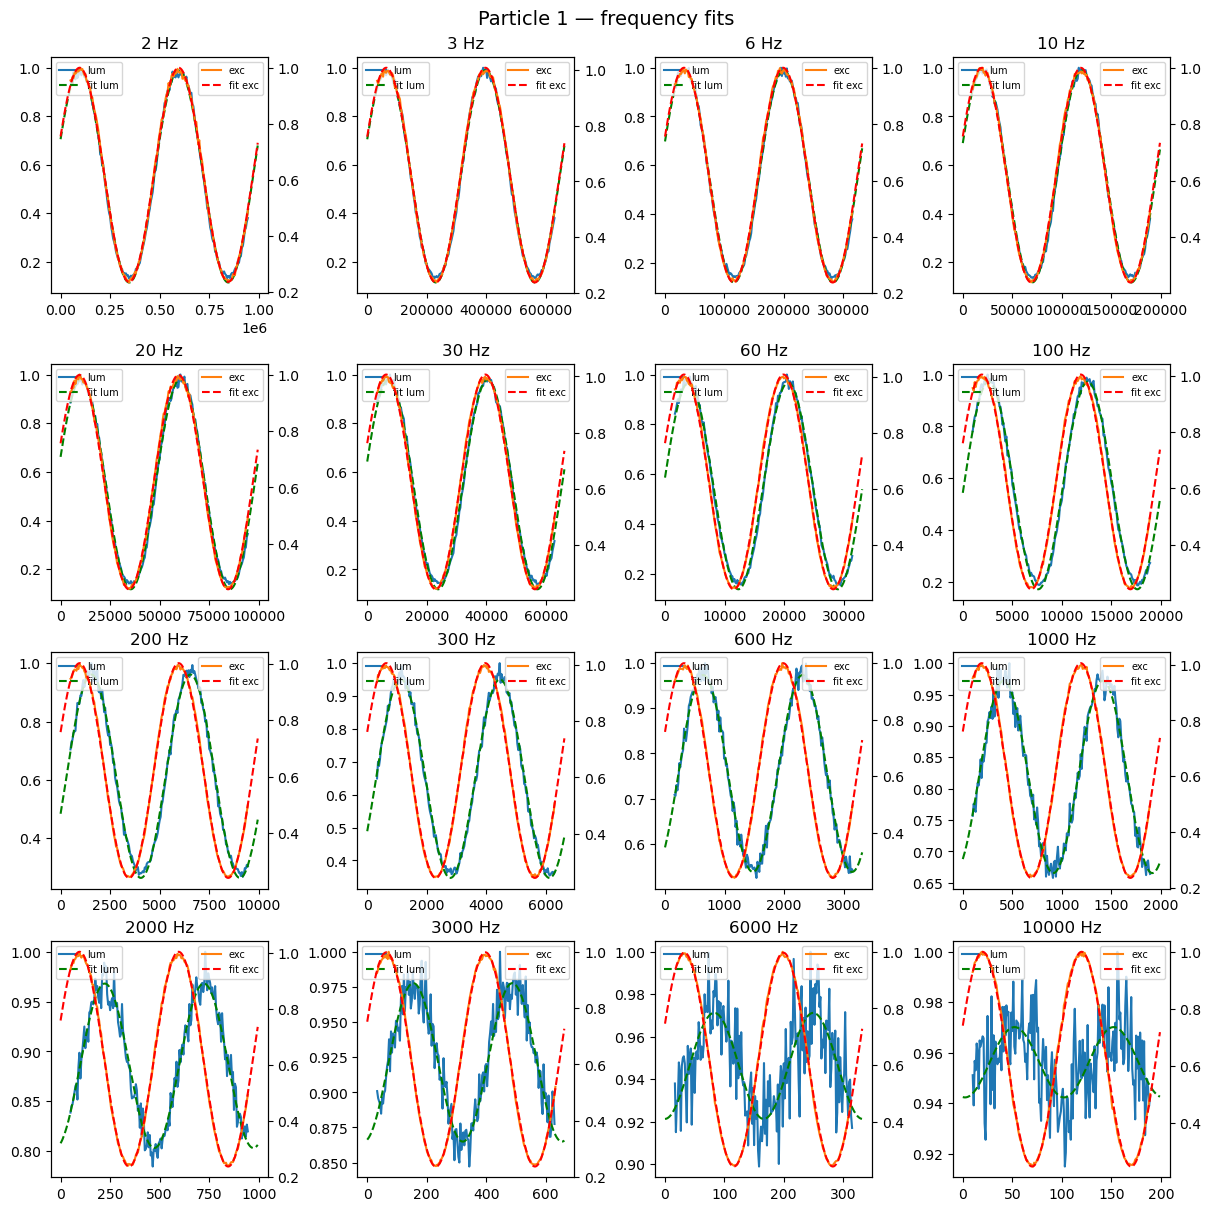

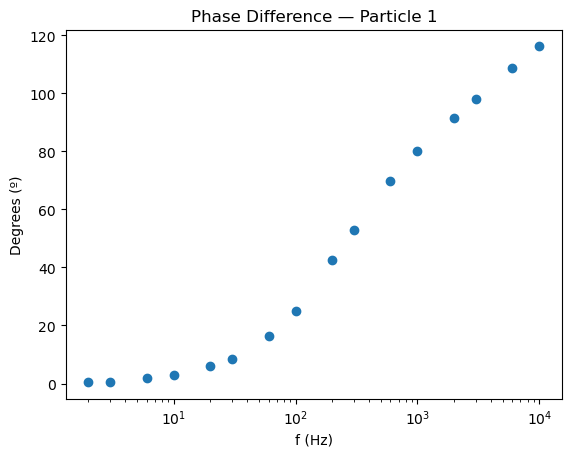

In [59]:
# Pré-carrega os dados de excitação uma única vez (são os mesmos para todas as partículas)
exc_data = {freq: np.loadtxt(f"{data_path_exc}/{freq}hz.txt") for freq in freq_list}

results = []   # armazena resultados de cada partícula

for p_idx, lum_path in enumerate(data_paths_lum):
    particle_label = f"Particle {p_idx + 1}"
    correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

    print(f"\n{'='*50}")
    print(f"  Processing {particle_label}")
    print(f"{'='*50}")

    omegas      = []
    phase_diffs = []

    # ---- Subplots de verificação visual ----
    fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
    fig.suptitle(f"{particle_label} — frequency fits", fontsize=14)

    for index, freq in enumerate(freq_list):
        i, j = divmod(index, cols)
        omega = 2 * np.pi * float(freq) * 1e-6
        omegas.append(omega)

        fitting_func = make_fitting_func(omega)
        p0 = fitting_problems[p_idx].get(freq, None)
        
        lum_curve = adj_data_shape(np.loadtxt(f"{lum_path}/{freq}hz.txt"))
        exc_curve = adj_data_shape(exc_data[freq])

        xs_exc, popt_exc = fit_curve(exc_curve, fitting_func, p0=p0)
        xs_lum, popt_lum = fit_curve(lum_curve, fitting_func, p0=p0)

        ph_exc = popt_exc[2]
        ph_lum = popt_lum[2]
        phase_diffs.append(np.degrees(ph_lum - ph_exc) % 360)

        # Plot normalizado
        x_exc, y_exc = shorten_points(exc_curve)
        x_lum, y_lum = shorten_points(lum_curve)

        ax = axs[i, j]
        ax.plot(x_lum, y_lum / np.max(y_lum), label="lum")
        ax.plot(xs_lum, fitting_func(xs_lum, *popt_lum) / np.max(y_lum), "g--", label="fit lum")
        ax.set_title(f"{freq} Hz")
        ax.legend(loc="upper left", fontsize=7)

        ax2 = ax.twinx()
        ax2.plot(x_exc, y_exc / np.max(y_exc), color="tab:orange", label="exc")
        ax2.plot(xs_exc, fitting_func(xs_exc, *popt_exc) / np.max(y_exc), "r--", label="fit exc")
        ax2.legend(loc="upper right", fontsize=7)

    plt.show()

    # ---- Diferença de fase desta partícula ----
    omega_arr = np.array(omegas)
    phase_arr = np.array(phase_diffs)

    plt.scatter(adj_omega(omega_arr), adj_ph(phase_arr, correct))
    plt.xscale("log")
    plt.title(f"Phase Difference — {particle_label}")
    plt.ylabel("Degrees (º)")
    plt.xlabel("f (Hz)")
    plt.show()

    results.append({"label": particle_label, "omegas": omega_arr, "phases": phase_arr, "correct": correct})

## Comparação — todas as partículas

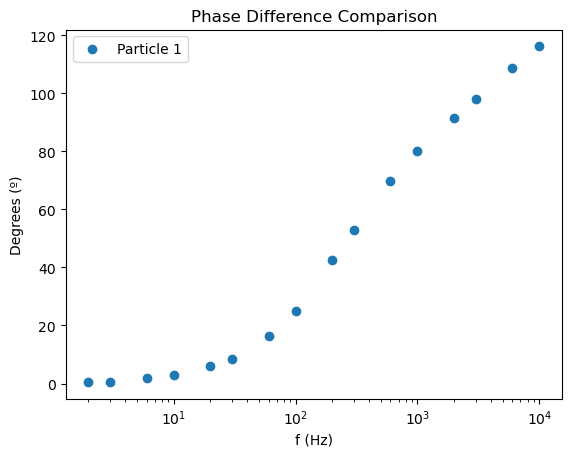

In [60]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, r in enumerate(results):
    color = colors[idx % len(colors)]
    plt.scatter(
        adj_omega(r["omegas"]),
        adj_ph(r["phases"], r["correct"]),
        label=r["label"],
        color=color,
    )
#Partícula 1: LRTIM, Partícula 2: GPTIM
plt.xscale("log")
plt.title("Phase Difference Comparison")
plt.ylabel("Degrees (º)")
plt.xlabel("f (Hz)")
plt.legend()
plt.show()

# Junk